# Earthworks: Bioswale

Brendan Harmon  
2025-08-20

<figure>
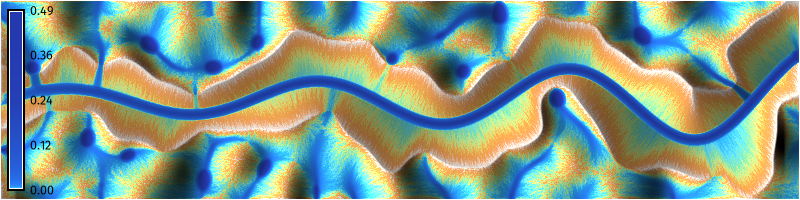
<figcaption aria-hidden="true">Bioswale</figcaption>
</figure>

Learn how to design, model, and simulate hydrologic systems such as
bioswales or restored streams. This tutorial covers the design of swales
using
[r.earthworks](https://grass.osgeo.org/grass-stable/manuals/addons/r.earthworks.html)
(Harmon, Petrasova, and Petras 2026) and the simulation of shallow
overland flows of water using
[r.sim.water](https://grass.osgeo.org/grass-stable/manuals/r.sim.water.html).
Bioswales are shallow, vegetated channels for conveying, filtering, and
infiltrating stormwater. They are designed to move stormwater slowly
enough through a site for retention, filtration, sedimentation, and
infiltration, yet quickly enough to prevent localized flooding. By
retaining and infiltrating stormwater, bioswales reduce the peak flow of
runoff during storm events, reducing the risk of flash flooding. In this
tutorial, we will use an iterative cycle of modeling and simulation to
design a landscape with a bioswale that stores stormwater on site and
conveys the overflow offsite.

While this tutorial uses Python to procedurally design a bioswale using
a trigonometric function, the process demonstrated here can easily be
adapted for the GRASS graphical user interface (GUI) or command line
interface (CLI) when working with real world sites. The centerline of
the channel can be drawn in the GUI using the raster digitizer
[g.gui.rdigit](https://grass.osgeo.org/grass-stable/manuals/g.gui.rdigit.html)
or vector digitizer
[g.gui.vdigit](https://grass.osgeo.org/grass-stable/manuals/g.gui.vdigit.html).
Alternatively if the channel is drawn in a computer-aided design
program, then it can be imported into GRASS as a 2D or 3D vector map.

Our process will be to:

-   Model the initial terrain
-   Simulate shallow overland water flow over the terrain
-   Design the bioswale
-   Model the bioswale
-   Simulate shallow water flow with the bioswale
-   Design planting for the bioswale
-   Simulate shallow water flow with the planted bioswale
-   Animate the shallow water flow simulation

> **Computational notebook**
>
> This tutorial can be run as a computational notebook. Learn how to
> work with notebooks in the tutorial [Get started with GRASS & Python
> in Jupyter
> Notebooks](https://grass-tutorials.osgeo.org/content/tutorials/get_started/fast_track_grass_and_python.html).

# Setup

Start a GRASS session in a new project with a Cartesian (XY) coordinate
system. Use
[g.region](https://grass.osgeo.org/grass-stable/manuals/g.region.html)
to set the extent and resolution of the computational region. Create a
region starting at the origin and extending two hundred units north and
eight hundred units east.

In [1]:
# Import libraries
import os
import sys
import subprocess
from pathlib import Path

# Find GRASS Python packages
sys.path.append(
  subprocess.check_output(
    ["grass", "--config", "python_path"],
    text=True
    ).strip()
  )

# Import GRASS packages
import grass.script as gs
import grass.jupyter as gj

# Create a temporary folder
import tempfile
temporary = tempfile.TemporaryDirectory()

# Create a project in the temporary directory
gs.create_project(path=temporary.name, name="xy")

# Start GRASS in this project
session = gj.init(Path(temporary.name, "xy"))

# Set region
gs.run_command("g.region", n=200, e=800, s=0, w=0, res=1)

## Installation

Install
[r.earthworks](https://grass.osgeo.org/grass-stable/manuals/addons/r.earthworks.html)
with
[g.extension](https://grass.osgeo.org/grass-stable/manuals/g.extension.html).

In [2]:
# Install extension
gs.run_command("g.extension", extension="r.earthworks")

# Initial Terrain

Model synthetic terrain using gradient noise. For a more detailed guide,
see the [Procedural Noise](noise.qmd) tutorial. First create a random
surface using the raster calculator
[r.mapcalc](https://grass.osgeo.org/grass-stable/manuals/r.mapcalc.html).
Then use a `for` loop to progressively smooth the random surface using
nearest neighbors analysis with
[r.neighbors](https://grass.osgeo.org/grass-stable/manuals/r.neighbors.html).
Calculate the average neighborhood using a circular moving window. The
resulting terrain will be smooth and undulating with many ridges and
valleys.

In [3]:
# Set parameters
amplitude = 1000.0
iterations = 3
wavelength = 33

# Generate random surface
gs.mapcalc(f"noise = rand(0, {amplitude})", seed=0)

# Generate perlin noise
for i in range(iterations):

    # Smooth noise
    gs.run_command(
      "r.neighbors",
      input="noise",
      output="noise",
      size=wavelength,
      method="average",
      flags="c",
      overwrite=True
      )

# Set color gradient
gs.run_command("r.colors", map="noise", color="viridis")

# Visualize
m = gj.Map(width=800)
m.d_rast(map="noise")
m.d_legend(raster="noise", font="FiraSans-Regular", at=(5, 95, 1, 3))
m.show()

# Save image
m.save("images/bioswale-01.webp")

<figure>
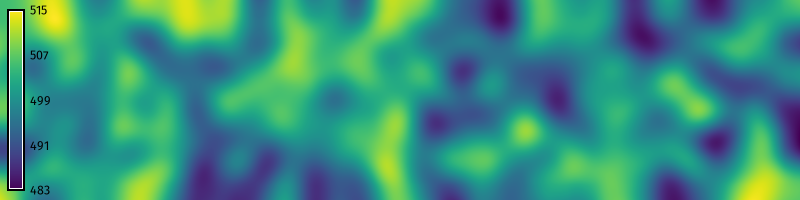
<figcaption aria-hidden="true">Initial terrain</figcaption>
</figure>

# Initial Hydrologic Simulation

How will this landscape perform in a storm event?

Run a simulation of shallow overland water flow to…

The valleys will fill with water, with pools forming in depressions.

[r.slope.aspect](https://grass.osgeo.org/grass-stable/manuals/r.slope.aspect.html)

[r.sim.water](https://grass.osgeo.org/grass-stable/manuals/r.sim.water.html)

[r.relief](https://grass.osgeo.org/grass-stable/manuals/r.relief.html)

[r.colors](https://grass.osgeo.org/grass-stable/manuals/r.colors.html)

In [4]:
# Compute partial derivatives of terrain
gs.run_command("r.slope.aspect", elevation="noise", dx="dx", dy="dy")

# Simulate shallow water flow
gs.run_command(
    "r.sim.water",
    elevation="noise",
    dx="dx",
    dy="dy",
    rain_value=150,
    nwalkers=10000,
    niterations=30,
    nprocs=10,
    depth="depth",
    discharge="discharge"
    )

# Compute shaded relief
gs.run_command("r.relief", input="noise", output="relief")

# Set color gradient
gs.run_command("r.colors", map="depth", color="haxby", flags="en")

# Visualize
m = gj.Map(width=800)
m.d_shade(shade="relief", color="depth", brighten=25)
m.d_legend(raster="depth", font="FiraSans-Regular", at=(5, 95, 1, 3))
m.show()

# Save image
m.save("images/bioswale-02.webp")

<figure>
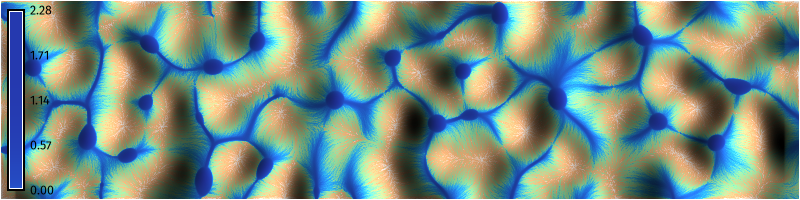
<figcaption aria-hidden="true">Initial water depth</figcaption>
</figure>

# Bioswale Design

[numpy.linspace](https://numpy.org/doc/stable/reference/generated/numpy.linspace.html)

[numpy.sin](https://numpy.org/doc/stable/reference/generated/numpy.sin.html)

[seaborn.scatterplot](https://seaborn.pydata.org/generated/seaborn.scatterplot.html)

[matplotlib.pyplot.plot](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.plot.html)

In [5]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt

# Set wave variables
n = 1000 # Steps
a = 10 # Amplitude
b = 0.025 # Scale
c = 0 # Horizontal shift
d = 100 # Vertical shift
f = 0.002 # Decay rate

# Set earthwork variables
rate=0.5
flat=6

# Plot sinusoidal wave
x = np.linspace(0, 800, n)
y = a * np.sin(b * x - c) * np.e**(f * x) + d 
z = np.linspace(490, 480, n)
coordinates = np.column_stack((x, y))

# Plot
plt.figure(figsize=(8, 2)) 
plt.plot(x, y)
plt.show()

For nicer plotting, use Seaborn. First install it using the package
manager pip.

In [6]:
%pip install seaborn

Then…

In [7]:
import seaborn as sns

# Set theme
sns.set_theme(
    context="paper", 
    style="darkgrid"
    )

# Plot
plot = sns.scatterplot(
    x=x,
    y=y,
    size=x,
    hue=-x,
    palette="viridis",
    edgecolor="none",
    legend=False
    )

# Save figure
fig = plot.get_figure()
fig.set_size_inches(8, 2)
fig.savefig(
    "images/bioswale-03.webp",
    dpi=150,
    bbox_inches="tight",
    pad_inches=0
    )

<figure>
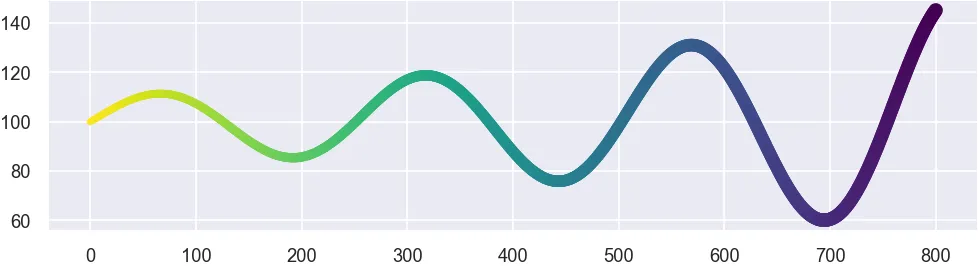
<figcaption aria-hidden="true">Sinusoidal wave</figcaption>
</figure>

# Bioswale Modeling

[r.earthworks](https://grass.osgeo.org/grass-stable/manuals/addons/r.earthworks.html)

In [8]:
# Model landforms
gs.run_command(
    "r.earthworks",
    elevation="noise",
    earthworks="bioswale",
    volume="volume",
    operation="cut",
    coordinates=coordinates,
    z=z,
    function="linear",
    linear=rate,
    flat=flat
    )

# Visualize
m = gj.Map(width=800)
m.d_rast(map="bioswale")
m.d_legend(raster="bioswale", font="FiraSans-Regular", at=(5, 95, 1, 3))
m.show()

# Save image
m.save("images/bioswale-04.webp")

<figure>
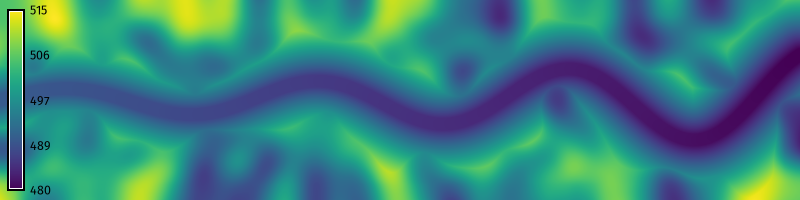
<figcaption aria-hidden="true">Terrain with bioswale</figcaption>
</figure>

# Hydrologic Simulation

In [9]:
# Compute partial derivatives of terrain
gs.run_command("r.slope.aspect", elevation="bioswale", dx="dx", dy="dy")

# Simulate shallow water flow
gs.run_command(
    "r.sim.water",
    elevation="bioswale",
    dx="dx",
    dy="dy",
    rain_value=150,
    nwalkers=10000,
    niterations=30,
    nprocs=10,
    depth="depth",
    discharge="discharge"
    )

# Compute shaded relief
gs.run_command("r.relief", input="bioswale", output="relief")

# Set color gradient
gs.run_command("r.colors", map="depth", color="haxby", flags="en")

# Visualize
m = gj.Map(width=800)
m.d_shade(shade="relief", color="depth", brighten=36)
m.d_legend(raster="depth", font="FiraSans-Regular", at=(5, 95, 1, 3))
m.show()

# Save image
m.save("images/bioswale-05.webp")

<figure>
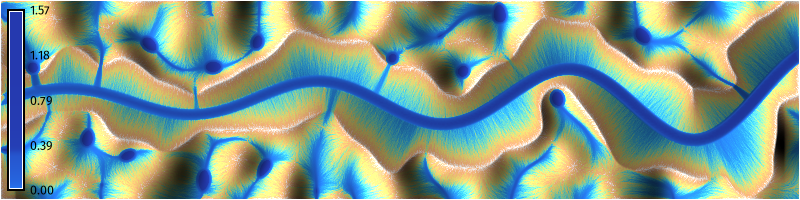
<figcaption aria-hidden="true">Water depth with bioswale</figcaption>
</figure>

# Planting Design

| Value | Category                      | Mannings | Runoff |
|-------|-------------------------------|----------|--------|
| 11    | Open Water                    | 0.001    | 1      |
| 21    | Developed, Open Space         | 0.0404   | 0.8    |
| 22    | Developed, Low Intensity      | 0.0678   | 0.85   |
| 23    | Developed, Medium Intensity   | 0.0678   | 0.9    |
| 24    | Developed, High Intensity     | 0.0404   | 0.95   |
| 31    | Barren Land                   | 0.0113   | 0.6    |
| 41    | Deciduous Forest              | 0.36     | 0.25   |
| 42    | Evergreen Forest              | 0.32     | 0.25   |
| 43    | Mixed Forest                  | 0.4      | 0.25   |
| 52    | Shrub/Scrub                   | 0.4      | 0.5    |
| 71    | Grassland/Herbaceuous         | 0.368    | 0.35   |
| 81    | Pasture/Hay                   | 0.325    | 0.35   |
| 82    | Cultivated Crops              | 0.325    | 0.4    |
| 90    | Woody Wetlands                | 0.086    | 0.25   |
| 95    | Emergent Herbaceuous Wetlands | 0.1825   | 0.25   |

In [10]:
# Define landcover colors
categories = """\
11|Open Water
12|Perennial Ice/Snow
21|Developed, Open Space
22|Developed, Low Intensity
23|Developed, Medium Intensity
24|Developed, High Intensity
31|Barren Land
41|Deciduous Forest
42|Evergreen Forest
43|Mixed Forest
51|Dwarf Scrub
52|Shrub/Scrub
71|Grassland/Herbaceuous
72|Sedge/Herbaceous
73|Lichens
74|Moss
81|Pasture/Hay
82|Cultivated Crops
90|Woody Wetlands
95|Emergent Herbaceuous Wetlands
"""

In [11]:
# Define mannings roughness values
mannings = """\
11:11:0.001:0.001
12:12:0.022:0.022
21:21:0.0404:0.0404
22:22:0.0678:0.0678
23:23:0.0678:0.0678
24:24:0.0404:0.0404
31:31:0.0113:0.0113
41:41:0.36:0.36
42:42:0.32:0.32
43:43:0.40:0.40
52:52:0.40:0.40
71:71:0.368:0.368
81:81:0.325:0.325
82:82:0.325:0.325
90:90:0.086:0.086
95:95:0.1825:0.1825
100:100:0.40:0.40
"""

In [12]:
# Define runoff rates
runoff = """\
11:11:1:1
12:12:0.95:0.95
21:21:0.8:0.8
22:22:0.85:0.85
23:23:0.9:0.9
24:24:0.95:0.95
31:31:0.6:0.6
41:41:0.25:0.25
42:42:0.25:0.25
43:43:0.25:0.25
52:52:0.5:0.5
71:71:0.35:0.35
81:81:0.35:0.35
82:82:0.4:0.4
90:90:0.25:0.25
95:95:0.25:0.25
100:100:0.25:0.25
"""

[r.mapcalc](https://grass.osgeo.org/grass-stable/manuals/r.mapcalc.html)

[r.colors](https://grass.osgeo.org/grass-stable/manuals/r.colors.html)

[r.category](https://grass.osgeo.org/grass-stable/manuals/r.category.html)

[r.recode](https://grass.osgeo.org/grass-stable/manuals/r.recode.html)

In [13]:
# Derive landcover from channel
gs.mapcalc("landcover = if(volume == 0, 71, 95)")

# Set landcover colors
gs.run_command("r.colors", map="landcover", color="nlcd")

# Set landcover categories
gs.write_command("r.category", map="landcover", separator="pipe", rules="-", stdin=categories)

# Derive mannings from landcover
gs.write_command("r.recode", input="landcover", output="mannings", rules="-", stdin=mannings)

# Derive runoff from landcover
rain = 150
gs.write_command("r.recode", input="landcover", output="runoff", rules="-", stdin=runoff)
gs.mapcalc(f"runoff = {rain} * runoff")

# Visualize
m = gj.Map(width=800)
m.d_rast(map="landcover")
m.d_legend(raster="landcover", font="FiraSans-Regular", fontsize=10, flags="n", at=(5, 95, 1, 3))
# m.d_legend(raster="landcover", font="FiraSans-Regular", fontsize=10, use=(71,95), at=(5, 95, 1, 3))
m.show()

# Save image
m.save("images/bioswale-06.webp")

<figure>
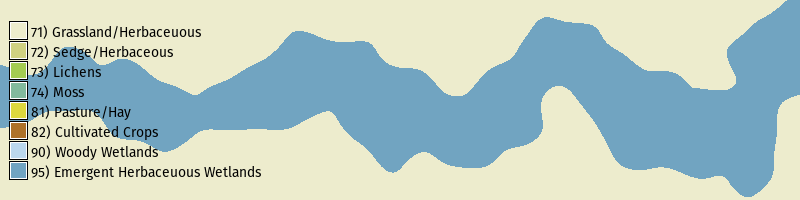
<figcaption aria-hidden="true">Landcover for bioswale</figcaption>
</figure>

# Hydrologic Simulation

In [14]:
# Simulate shallow water flow
gs.run_command(
    "r.sim.water",
    elevation="bioswale",
    dx="dx",
    dy="dy",
    man="mannings",
    rain="runoff",
    nwalkers=10000,
    niterations=30,
    nprocs=10,
    depth="depth",
    discharge="discharge"
    )

# Compute shaded relief
gs.run_command("r.relief", input="bioswale", output="relief")

# Set color gradient
gs.run_command("r.colors", map="depth", color="haxby", flags="en")

# Visualize
m = gj.Map(width=800)
m.d_shade(shade="relief", color="depth", brighten=36)
m.d_legend(raster="depth", font="FiraSans-Regular", at=(5, 95, 1, 3))
m.show()

# Save image
m.save("images/bioswale-07.webp")

<figure>
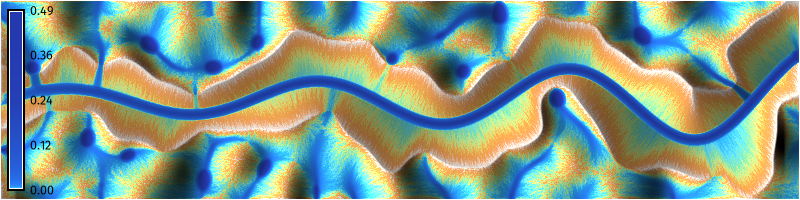
<figcaption aria-hidden="true">Water depth with planted
bioswale</figcaption>
</figure>

# Animation

[r.sim.water](https://grass.osgeo.org/grass-stable/manuals/r.sim.water.html)

[script.core.list_strings](https://grass.osgeo.org/grass85/manuals/libpython/script.html#script.core.list_strings)

[t.create](https://grass.osgeo.org/grass-stable/manuals/t.create.html)

[t.register](https://grass.osgeo.org/grass-stable/manuals/t.register.html)

[t.rast.colors](https://grass.osgeo.org/grass-stable/manuals/t.rast.colors.html)

[g.gui.animation](https://grass.osgeo.org/grass-stable/manuals/g.gui.animation.html)

[grass.jupyter.TimeSeriesMap](https://grass.osgeo.org/grass85/manuals/libpython/grass.jupyter.html#grass.jupyter.TimeSeriesMap)

In [15]:
# Simulate shallow water flow as time series
gs.run_command(
    "r.sim.water",
    elevation="bioswale",
    dx="dx",
    dy="dy",
    man="mannings",
    rain="runoff",
    nwalkers=10000,
    niterations=30,
    output_step=1,
    nprocs=10,
    depth="depth",
    discharge="discharge",
    flags="t"
    )

# List depth rasters
rasters = gs.list_strings(type="rast", pattern="depth.*")

# Create space time raster dataset
gs.run_command(
    "t.create", 
    type="strds",
    temporaltype="relative",
    semantictype="sum",
    output="depth",
    title="depth",
    description="depth"
    )

# Register depth rasters
gs.run_command(
    "t.register",
    input="depth",
    maps=rasters,
    type="raster",
    start=0,
    unit="minutes",
    increment=1,
    separator="comma",
    flags="i"
    )

# Set time series color gradient
gs.run_command("t.rast.colors", input="depth", color="haxby", flags="en")

# Animate time series
depth = gj.TimeSeriesMap(width=800)
depth.add_raster_series("depth")
depth.d_legend()
depth.show()

<figure>
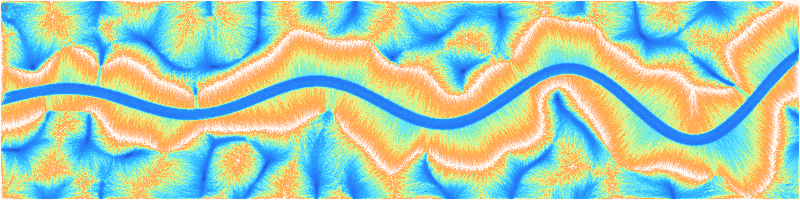
<figcaption aria-hidden="true">Water depth animation</figcaption>
</figure>

Harmon, Brendan, Anna Petrasova, and Vaclav Petras. 2026.
“<span class="nocase">r.earthworks:</span> A GRASS Tool for Terrain
Modeling.” *Journal of Open Source Software* 11 (118): 9270.
<https://doi.org/10.21105/joss.09270>.